In [1]:
from datasets import load_dataset, DatasetDict

hf_nature_ds = load_dataset("mertcobanov/nature-dataset")
split = hf_nature_ds["train"].train_test_split(test_size=0.4, seed=42)
hf_nature_unseperated_ds = DatasetDict({
    "train": split["train"],
    "validation\test": split["test"]
})
validation_test_split = hf_nature_unseperated_ds["validation\test"].train_test_split(test_size=0.5, seed=42)
hf_nature_ds = DatasetDict({
    "train": hf_nature_unseperated_ds["train"],
    "validation": validation_test_split["train"],
    "test": validation_test_split["test"]
})
hf_nature_ds

README.md:   0%|          | 0.00/406 [00:00<?, ?B/s]

data/train-00000-of-00005-e93cb538dd6e75(…):   0%|          | 0.00/513M [00:00<?, ?B/s]

data/train-00001-of-00005-a70efa7808d4d2(…):   0%|          | 0.00/524M [00:00<?, ?B/s]

data/train-00002-of-00005-b9a06f86c921b2(…):   0%|          | 0.00/520M [00:00<?, ?B/s]

data/train-00003-of-00005-b0d241758db4d2(…):   0%|          | 0.00/539M [00:00<?, ?B/s]

data/train-00004-of-00005-867c118c76edb3(…):   0%|          | 0.00/517M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 30000
    })
    validation: Dataset({
        features: ['image', 'caption'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['image', 'caption'],
        num_rows: 10000
    })
})

In [2]:
from datasets import load_dataset, DatasetDict

NOT_TRAVERSIBLE_KEYWORDS = {
    # Water
    "water", "ocean", "river", "lake", "stream", "pond",
    "waterfall", "flood", "swamp", "marsh", "sea",
    # Hazardous terrain
    "cliff", "steep", "ravine", "gorge", "canyon",
    "chasm", "precipice",
    # Dense vegetation
    "thicket", "bramble",
    # Other
    "lava", "quicksand", "mud", "snow", "ice", "glacier", "wall", "mountain"
}

def label_traversibility(example):
    caption = example["caption"].lower()
    # Tokenize on word boundaries to avoid partial matches
    words = set(caption.replace(",", " ").replace(".", " ").split())
    is_not_traversible = bool(words & NOT_TRAVERSIBLE_KEYWORDS)
    # Label = 0 if not traversable, 1 = traversible
    return {"label": 0 if is_not_traversible else 1}

hf_nature_ds = hf_nature_ds.map(label_traversibility)
hf_nature_ds = hf_nature_ds.remove_columns("caption")
hf_nature_ds


Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 30000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

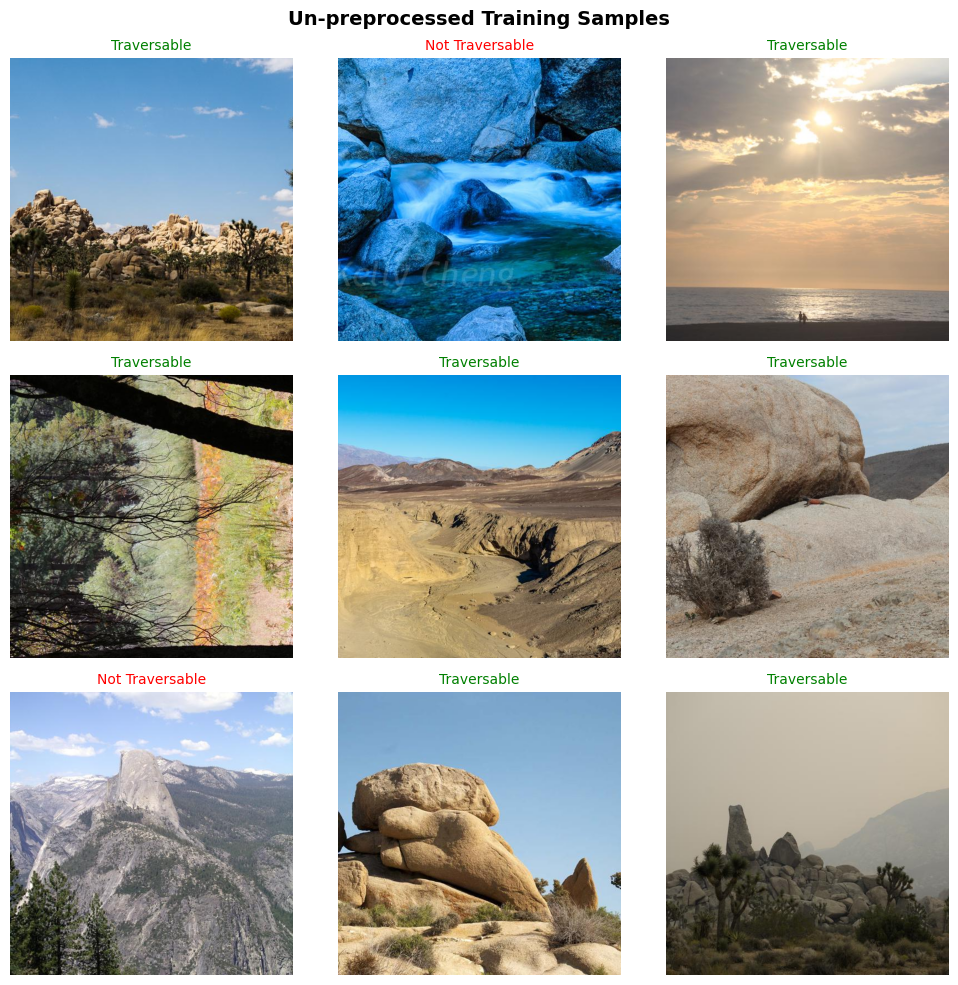

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_samples(dataset, num_samples=9, cols=3):
    rows = num_samples // cols
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    fig.suptitle("Un-preprocessed Training Samples", fontsize=14, fontweight="bold")

    # Grab a batch of samples
    samples = dataset["train"].shuffle(seed=42).select(range(num_samples))

    for i, example in enumerate(samples):
        ax = axes[i // cols, i % cols]

        image = np.array(example["image"])
        label = example["label"]
        label_name = "Traversable" if label == 1 else "Not Traversable"

        # Squeeze grayscale channel dim (92, 92, 1) → (92, 92)
        ax.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(label_name, fontsize=10,
                     color="green" if label == 1 else "red")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("training_samples.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_training_samples(hf_nature_ds)

In [4]:
import os
import tensorflow as tf
from tensorflow.data import Dataset as TFDataset
num_cpus = os.cpu_count() if os.cpu_count() is not None else 1
# Now, split into training and validation tensorflow datasets
train_nature_ds: TFDataset = hf_nature_ds["train"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=True
)
validation_nature_ds: TFDataset = hf_nature_ds["validation"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=False
)
test_nature_ds: TFDataset = hf_nature_ds["test"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=False
)
train_nature_ds, validation_nature_ds, test_nature_ds

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

In [5]:
import cv2
import numpy as np
import tensorflow as tf # Ensure tf is imported for tf.cast

def preprocess(image, label):
    # Convert to grayscale (H, W, 1)
    image = tf.image.rgb_to_grayscale(image)
    # Resize to (92, 92)
    image = tf.image.resize(image, (92, 92))
    # Cast to uint8 for space
    image = tf.cast(image, tf.uint8)

    return image, label

# Apply preprocess to individual images, then batch and prefetch
train_nature_ds = train_nature_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
validation_nature_ds = validation_nature_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
test_nature_ds = test_nature_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

# Expand labels to leave TensorSpec(shape=(None, )) to TensorSpec(shape=(None, 1)), allowing for tensorflow metrics
def expand_labels(image, label):
    label = tf.expand_dims(label, axis=-1)
    return image, label

train_nature_ds = train_nature_ds.map(expand_labels)
validation_nature_ds = validation_nature_ds.map(expand_labels)
test_nature_ds = test_nature_ds.map(expand_labels)

train_nature_ds, validation_nature_ds, test_nature_ds

(<_MapDataset element_spec=(TensorSpec(shape=(None, 92, 92, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>,
 <_MapDataset element_spec=(TensorSpec(shape=(None, 92, 92, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>,
 <_MapDataset element_spec=(TensorSpec(shape=(None, 92, 92, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>)

In [6]:
image, label = next(iter(train_nature_ds))

image.shape

TensorShape([32, 92, 92, 1])

In [17]:
num_traversible, num_not_traversible = 0, 0
images_traversed = 0
for(image, label) in train_nature_ds.unbatch():
    if label == 1:
        num_traversible += 1
    else:
        num_not_traversible += 1
    images_traversed += 1
    if(images_traversed % 1000 == 0):
      print(f"Processed {images_traversed}")
num_traversible, num_not_traversible

Processed 1000
Processed 2000
Processed 3000
Processed 4000
Processed 5000
Processed 6000
Processed 7000
Processed 8000
Processed 9000
Processed 10000
Processed 11000
Processed 12000
Processed 13000
Processed 14000
Processed 15000
Processed 16000
Processed 17000
Processed 18000
Processed 19000
Processed 20000
Processed 21000
Processed 22000
Processed 23000
Processed 24000
Processed 25000
Processed 26000
Processed 27000
Processed 28000
Processed 29000
Processed 30000


(14964, 15036)

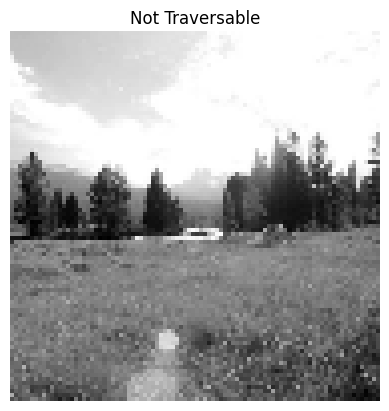

In [7]:
plt.imshow(image[0].numpy().squeeze(), cmap="gray")
plt.title("Traversable" if label[0] == 1 else "Not Traversable")
plt.axis("off")
plt.show()

In [10]:
# Create the model...
model = tf.keras.Sequential([ # Analagous to nn.Sequential in PyTorch
    # Block 1
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same", input_shape=(92, 92, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    # Block 2
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    # Classifier
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation="sigmoid")  # binary classification
], name="TinyVGG")

model.summary()

Model: "TinyVGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 92, 92, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 46, 46, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,673 (205.75 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the model & Run the epochs
EPOCHS: int = 20
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"), # of all predicted positives, how many were correct
        tf.keras.metrics.Recall(name="recall"), # of all true positives, how many were predicted
        tf.keras.metrics.AUC(name="auc"), # area under ROC curve 1.0 = perfect, 0.5 = random
        tf.keras.metrics.F1Score(threshold=0.5)
    ]
)

model.fit(
    train_nature_ds,
    validation_data=validation_nature_ds,
    epochs=EPOCHS
)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 259s 274ms/step - accuracy: 0.5460 - auc: 0.5655 - f1_score: 0.5634 - loss: 1.2900 - precision: 0.5414 - recall: 0.5873 - val_accuracy: 0.5629 - val_auc: 0.5981 - val_f1_score: 0.6108 - val_loss: 0.6808 - val_precision: 0.5503 - val_recall: 0.6863
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 257s 274ms/step - accuracy: 0.5814 - auc: 0.6108 - f1_score: 0.5770 - loss: 0.6739 - precision: 0.5817 - recall: 0.5724 - val_accuracy: 0.5832 - val_auc: 0.6193 - val_f1_score: 0.5960 - val_loss: 0.6797 - val_precision: 0.5780 - val_recall: 0.6150
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 258s 276ms/step - accuracy: 0.6004 - auc: 0.6403 - f1_score: 0.5892 - loss: 0.6621 - precision: 0.6046 - recall: 0.5744 - val_accuracy: 0.5804 - val_auc: 0.6028 - val_f1_score: 0.5367 - val_loss: 0.6915 - val_precision: 0.5988 - val_recall: 0.4862
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 258s 275ms/step - accuracy: 0.6096 - auc: 0.6560 - f1_score: 0.6023 - loss: 0.6505 - precision: 

In [12]:
model.evaluate(test_nature_ds)

313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 204ms/step - accuracy: 0.5830 - auc: 0.6051 - f1_score: 0.5579 - loss: 1.5853 - precision: 0.5916 - recall: 0.5278


[1.5852551460266113,
 0.5830000042915344,
 0.5916348099708557,
 0.5277833342552185,
 0.6050621867179871,
 0.5578879714012146]

In [22]:
# Quantize
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

# Save to Google Drive
from google.colab import drive
drive.mount('/content/drive')

with open("/content/drive/MyDrive/tinyvgg_terrain_quantized.tflite", "wb") as f:
    f.write(tflite_model)

print(f"Quantized model size: {len(tflite_model) / 1024:.2f} KB")
print("Model saved to Google Drive!")

Saved artifact at '/tmp/tmplcj3wkjj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 92, 92, 1), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138544611482256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138544611484368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138544611485712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138544611482832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138544611485136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138544611486672: TensorSpec(shape=(), dtype=tf.resource, name=None)
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Quantized model size: 56.85 KB
Model saved to Google Drive!
